# AIS Trajectory Prediction — LSTM Baseline vs TrAISformer-style Transformer

**Goal:** predict a vessel's next position from its recent AIS history, so actual-vs-predicted deviation can be used as a trajectory-based anomaly signal (per PS 26143's "trajectory based deviation" ask).

Two models, trained and evaluated identically so the comparison is clean:
- **Baseline: LSTM regression** — predicts next (lat, lon) directly from a continuous feature sequence. This is the architecture your 2022 teammate's submission explored (per the deck) but never fully implemented/scored, so there's no existing number to reproduce -- this run establishes the baseline itself.
- **Challenger: TrAISformer-style Transformer** — based on Nguyen et al.'s AIS-specific transformer: each of (lat, lon, speed, course) is discretized into bins and embedded ("four-hot" embedding), fed through a causally-masked transformer encoder, and the model predicts a *distribution* over next-position bins rather than a single regression value. This is the actual published architecture for this exact problem, not a generic transformer swap.

**Evaluation split:** by **vessel**, not by time. A vessel's own trajectory patterns (turning habits, typical speed) leak across time-based splits if the same vessel appears in both train and test -- same leakage class of mistake as the AIS anomaly detection issue we already caught. Held-out vessels here are genuinely unseen during training.

**Metric:** ADE / FDE (Average / Final Displacement Error) in kilometers via haversine distance -- the standard metric for trajectory prediction, far more interpretable than raw MSE on lat/lon degrees.


In [1]:
# CELL 1: Imports
import os, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingLR
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    _test = torch.randn(4, 4).to(device)
    _ = (_test @ _test).sum().item()
    print(f"GPU sanity check passed: {torch.cuda.get_device_name(0)}")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


Using device: cuda
GPU sanity check passed: Tesla T4


In [2]:
# CELL 2: Config
DATA_PATH = "/kaggle/input/datasets/antareepghosh/mauritius/Maritius_AOI_20200701_0731_full.csv"

MIN_PINGS_PER_VESSEL = 20   # below this, a vessel doesn't have enough history to form
                             # a useful windowed sequence -- checked against the actual
                             # distribution: 184/231 vessels clear this bar (79.7%), covering
                             # 27,579 of 27,978 rows, so this is not a large data loss.
SEQ_LEN = 8                 # steps of history used as input
BATCH_SIZE = 64
EPOCHS = 40
LR = 1e-3

# discretization bin counts for the TrAISformer-style model
N_LAT_BINS = 200
N_LON_BINS = 200
N_SPEED_BINS = 30
N_COURSE_BINS = 72   # 5-degree resolution


In [3]:
# CELL 3: Load data, build vessel-level sequences, split by VESSEL (not time)

df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', utc=True)
df = df.sort_values(['mmsi', 'timestamp'])

for col in ['speed', 'course', 'rot', 'latitude', 'longitude']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['speed', 'course', 'rot', 'latitude', 'longitude'])

vessel_counts = df.groupby('mmsi').size()
qualifying_vessels = vessel_counts[vessel_counts >= MIN_PINGS_PER_VESSEL].index.tolist()
print(f"Qualifying vessels (>= {MIN_PINGS_PER_VESSEL} pings): {len(qualifying_vessels)} / {df['mmsi'].nunique()}")

df = df[df['mmsi'].isin(qualifying_vessels)].reset_index(drop=True)

# data ranges for normalization / discretization -- computed on ALL qualifying data
# (this is a preprocessing statistic, not a label, so it's fine to compute globally)
LAT_MIN, LAT_MAX = df['latitude'].min(), df['latitude'].max()
LON_MIN, LON_MAX = df['longitude'].min(), df['longitude'].max()
SPEED_MAX = df['speed'].quantile(0.999)  # clip extreme outlier speeds

def build_sequences(vessel_df, seq_len=SEQ_LEN):
    """Sliding window: seq_len steps of history -> next step (lat, lon)."""
    seqs, targets = [], []
    vals = vessel_df[['latitude','longitude','speed','course','rot']].values
    for i in range(len(vals) - seq_len):
        seqs.append(vals[i:i+seq_len])
        targets.append(vals[i+seq_len][:2])  # next (lat, lon)
    return seqs, targets

# vessel-level split: 80% train / 10% val / 10% test vessels
random.shuffle(qualifying_vessels)
n = len(qualifying_vessels)
train_vessels = set(qualifying_vessels[:int(0.8*n)])
val_vessels = set(qualifying_vessels[int(0.8*n):int(0.9*n)])
test_vessels = set(qualifying_vessels[int(0.9*n):])

def collect(vessel_set):
    all_seqs, all_targets = [], []
    for mmsi, g in df[df['mmsi'].isin(vessel_set)].groupby('mmsi'):
        s, t = build_sequences(g)
        all_seqs.extend(s); all_targets.extend(t)
    return np.array(all_seqs), np.array(all_targets)

X_train, y_train = collect(train_vessels)
X_val, y_val = collect(val_vessels)
X_test, y_test = collect(test_vessels)

print(f"Train sequences: {len(X_train)} (from {len(train_vessels)} vessels)")
print(f"Val sequences:   {len(X_val)} (from {len(val_vessels)} vessels)")
print(f"Test sequences:  {len(X_test)} (from {len(test_vessels)} vessels)")


Qualifying vessels (>= 20 pings): 180 / 226
Train sequences: 19523 (from 144 vessels)
Val sequences:   3111 (from 18 vessels)
Test sequences:  2569 (from 18 vessels)


In [4]:
# CELL 4: Haversine distance (for metrics) + shared normalization helpers

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def normalize_features(seq):
    """seq: [..., 5] -> (lat, lon, speed, course, rot), returns normalized copy."""
    out = seq.copy().astype(np.float32)
    out[..., 0] = (seq[..., 0] - LAT_MIN) / (LAT_MAX - LAT_MIN + 1e-9)
    out[..., 1] = (seq[..., 1] - LON_MIN) / (LON_MAX - LON_MIN + 1e-9)
    out[..., 2] = np.clip(seq[..., 2], 0, SPEED_MAX) / SPEED_MAX
    course_rad = np.radians(seq[..., 3])
    sin_c, cos_c = np.sin(course_rad), np.cos(course_rad)
    rot_norm = np.clip(seq[..., 4], -128, 128) / 128.0
    return np.concatenate([out[..., :3], sin_c[..., None], cos_c[..., None], rot_norm[..., None]], axis=-1)

def denorm_latlon(lat_norm, lon_norm):
    lat = lat_norm * (LAT_MAX - LAT_MIN) + LAT_MIN
    lon = lon_norm * (LON_MAX - LON_MIN) + LON_MIN
    return lat, lon


In [5]:
# CELL 5: BASELINE -- LSTM regression model

class LSTMTrajectoryModel(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.1)
        self.head = nn.Linear(hidden_dim, 2)  # predicts normalized (lat, lon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])  # use last timestep's hidden state


class TrajDataset(Dataset):
    def __init__(self, X, y):
        self.X = normalize_features(X)
        # targets normalized the same way as lat/lon in features
        self.y = np.stack([
            (y[:, 0] - LAT_MIN) / (LAT_MAX - LAT_MIN + 1e-9),
            (y[:, 1] - LON_MIN) / (LON_MAX - LON_MIN + 1e-9),
        ], axis=-1).astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)


train_loader = DataLoader(TrajDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TrajDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TrajDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)


In [6]:
# CELL 6: Train LSTM baseline

def train_lstm(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            running += loss.item()
        scheduler.step()
        train_losses.append(running / len(train_loader))

        model.eval()
        with torch.no_grad():
            vrunning = sum(criterion(model(xb.to(device)), yb.to(device)).item() for xb, yb in val_loader)
        val_losses.append(vrunning / len(val_loader))

        if (epoch+1) % 5 == 0 or epoch == epochs-1:
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_losses[-1]:.5f} | Val Loss: {val_losses[-1]:.5f}")

    return train_losses, val_losses


print("="*55, "\nTraining LSTM baseline\n", "="*55)
lstm_model = LSTMTrajectoryModel().to(device)
lstm_train_losses, lstm_val_losses = train_lstm(lstm_model, train_loader, val_loader)


Training LSTM baseline
Epoch [5/40] Train Loss: 0.00042 | Val Loss: 0.00023
Epoch [10/40] Train Loss: 0.00023 | Val Loss: 0.00013
Epoch [15/40] Train Loss: 0.00018 | Val Loss: 0.00011
Epoch [20/40] Train Loss: 0.00015 | Val Loss: 0.00017
Epoch [25/40] Train Loss: 0.00012 | Val Loss: 0.00008
Epoch [30/40] Train Loss: 0.00011 | Val Loss: 0.00007
Epoch [35/40] Train Loss: 0.00011 | Val Loss: 0.00008
Epoch [40/40] Train Loss: 0.00010 | Val Loss: 0.00006


In [7]:
# CELL 7: CHALLENGER -- TrAISformer-style discretized Transformer
# Reference: Nguyen et al., "A Transformer Network for GPS Trajectory Prediction" (TrAISformer).
# Each attribute (lat, lon, speed, course) is discretized into bins and embedded separately
# ("four-hot" encoding), summed, then passed through a causally-masked transformer encoder.
# The model predicts a DISTRIBUTION over next-position bins (classification), not a direct
# regression value -- this is what makes it meaningfully different from "just add attention."

def discretize(seq):
    """seq: [..., 5] raw (lat, lon, speed, course, rot) -> integer bin indices [..., 4]"""
    lat_bin = np.clip(((seq[...,0]-LAT_MIN)/(LAT_MAX-LAT_MIN+1e-9)*N_LAT_BINS).astype(int), 0, N_LAT_BINS-1)
    lon_bin = np.clip(((seq[...,1]-LON_MIN)/(LON_MAX-LON_MIN+1e-9)*N_LON_BINS).astype(int), 0, N_LON_BINS-1)
    speed_bin = np.clip((np.clip(seq[...,2],0,SPEED_MAX)/SPEED_MAX*N_SPEED_BINS).astype(int), 0, N_SPEED_BINS-1)
    course_bin = np.clip(((seq[...,3]%360)/360*N_COURSE_BINS).astype(int), 0, N_COURSE_BINS-1)
    return np.stack([lat_bin, lon_bin, speed_bin, course_bin], axis=-1)

def bin_to_latlon(lat_bin, lon_bin):
    lat_norm = (lat_bin + 0.5) / N_LAT_BINS
    lon_norm = (lon_bin + 0.5) / N_LON_BINS
    return denorm_latlon(lat_norm, lon_norm)


class TrAISformerDataset(Dataset):
    def __init__(self, X, y):
        self.bins = discretize(X)  # [N, seq_len, 4]
        y_full = np.concatenate([y, np.zeros((len(y), 3))], axis=-1)  # pad to reuse discretize()
        self.target_bins = discretize(y_full[:, None, :])[:, 0, :2]  # only need lat/lon bins of target

    def __len__(self):
        return len(self.bins)

    def __getitem__(self, idx):
        return torch.tensor(self.bins[idx], dtype=torch.long), torch.tensor(self.target_bins[idx], dtype=torch.long)


class TrAISformer(nn.Module):
    def __init__(self, d_model=128, n_heads=4, n_layers=3, seq_len=SEQ_LEN):
        super().__init__()
        self.lat_emb = nn.Embedding(N_LAT_BINS, d_model)
        self.lon_emb = nn.Embedding(N_LON_BINS, d_model)
        self.speed_emb = nn.Embedding(N_SPEED_BINS, d_model)
        self.course_emb = nn.Embedding(N_COURSE_BINS, d_model)
        self.pos_emb = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                                                     dim_feedforward=d_model*4,
                                                     dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.lat_head = nn.Linear(d_model, N_LAT_BINS)
        self.lon_head = nn.Linear(d_model, N_LON_BINS)

    def forward(self, bins):
        # bins: [B, seq_len, 4] -> (lat, lon, speed, course) bin indices
        x = (self.lat_emb(bins[...,0]) + self.lon_emb(bins[...,1]) +
             self.speed_emb(bins[...,2]) + self.course_emb(bins[...,3]))
        x = x + self.pos_emb

        seq_len = x.size(1)
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        x = self.transformer(x, mask=causal_mask)

        last_hidden = x[:, -1, :]
        return self.lat_head(last_hidden), self.lon_head(last_hidden)


traisformer_train_loader = DataLoader(TrAISformerDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
traisformer_val_loader = DataLoader(TrAISformerDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
traisformer_test_loader = DataLoader(TrAISformerDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)


In [8]:
# CELL 8: Train TrAISformer

def train_traisformer(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for bins, target_bins in train_loader:
            bins, target_bins = bins.to(device), target_bins.to(device)
            optimizer.zero_grad()
            lat_logits, lon_logits = model(bins)
            loss = criterion(lat_logits, target_bins[:,0]) + criterion(lon_logits, target_bins[:,1])
            loss.backward()
            optimizer.step()
            running += loss.item()
        scheduler.step()
        train_losses.append(running / len(train_loader))

        model.eval()
        with torch.no_grad():
            vrunning = 0.0
            for bins, target_bins in val_loader:
                bins, target_bins = bins.to(device), target_bins.to(device)
                lat_logits, lon_logits = model(bins)
                vrunning += (criterion(lat_logits, target_bins[:,0]) + criterion(lon_logits, target_bins[:,1])).item()
        val_losses.append(vrunning / len(val_loader))

        if (epoch+1) % 5 == 0 or epoch == epochs-1:
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses


print("="*55, "\nTraining TrAISformer\n", "="*55)
traisformer_model = TrAISformer().to(device)
traisformer_train_losses, traisformer_val_losses = train_traisformer(
    traisformer_model, traisformer_train_loader, traisformer_val_loader)


Training TrAISformer
Epoch [5/40] Train Loss: 1.7216 | Val Loss: 2.8767
Epoch [10/40] Train Loss: 1.1374 | Val Loss: 3.2058
Epoch [15/40] Train Loss: 0.7747 | Val Loss: 3.5461
Epoch [20/40] Train Loss: 0.5589 | Val Loss: 3.8894
Epoch [25/40] Train Loss: 0.3817 | Val Loss: 4.0903
Epoch [30/40] Train Loss: 0.2591 | Val Loss: 4.3239
Epoch [35/40] Train Loss: 0.1840 | Val Loss: 4.4626
Epoch [40/40] Train Loss: 0.1653 | Val Loss: 4.4901


In [9]:
# CELL 9: Evaluation -- ADE / FDE in km on the held-out TEST vessels for both models
# (single-step prediction here, so ADE == FDE == mean displacement error; kept as
# separate named metrics for consistency with standard trajectory-prediction reporting
# and to make this easy to extend to multi-step rollout later.)

@torch.no_grad()
def evaluate_lstm(model, loader):
    model.eval()
    errors = []
    for xb, yb in loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        true = yb.numpy()
        pred_lat, pred_lon = denorm_latlon(pred[:,0], pred[:,1])
        true_lat, true_lon = denorm_latlon(true[:,0], true[:,1])
        errors.extend(haversine_km(pred_lat, pred_lon, true_lat, true_lon))
    return np.array(errors)

@torch.no_grad()
def evaluate_traisformer(model, loader):
    model.eval()
    errors = []
    for bins, target_bins in loader:
        bins = bins.to(device)
        lat_logits, lon_logits = model(bins)
        pred_lat_bin = torch.argmax(lat_logits, dim=-1).cpu().numpy()
        pred_lon_bin = torch.argmax(lon_logits, dim=-1).cpu().numpy()
        pred_lat, pred_lon = bin_to_latlon(pred_lat_bin, pred_lon_bin)
        true_lat, true_lon = bin_to_latlon(target_bins[:,0].numpy(), target_bins[:,1].numpy())
        errors.extend(haversine_km(pred_lat, pred_lon, true_lat, true_lon))
    return np.array(errors)


lstm_errors = evaluate_lstm(lstm_model, test_loader)
traisformer_errors = evaluate_traisformer(traisformer_model, traisformer_test_loader)

print(f"LSTM baseline        -- ADE: {lstm_errors.mean():.4f} km | Median: {np.median(lstm_errors):.4f} km | P90: {np.percentile(lstm_errors,90):.4f} km")
print(f"TrAISformer          -- ADE: {traisformer_errors.mean():.4f} km | Median: {np.median(traisformer_errors):.4f} km | P90: {np.percentile(traisformer_errors,90):.4f} km")
print(f"\nNote: TrAISformer has an inherent quantization floor from discretization")
print(f"(~half a bin width in both lat and lon), so its error won't go to zero even with")
print(f"perfect classification. Bin width in this AOI: lat ~{(LAT_MAX-LAT_MIN)/N_LAT_BINS*111:.3f} km, lon ~{(LON_MAX-LON_MIN)/N_LON_BINS*111:.3f} km")


LSTM baseline        -- ADE: 0.3685 km | Median: 0.1928 km | P90: 0.6266 km
TrAISformer          -- ADE: 2.6175 km | Median: 0.3406 km | P90: 6.7824 km

Note: TrAISformer has an inherent quantization floor from discretization
(~half a bin width in both lat and lon), so its error won't go to zero even with
perfect classification. Bin width in this AOI: lat ~0.282 km, lon ~0.363 km


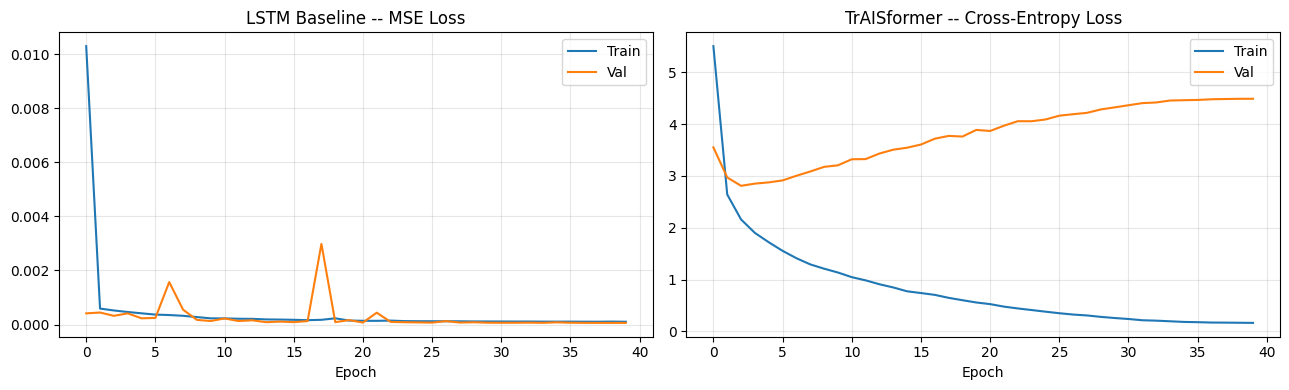

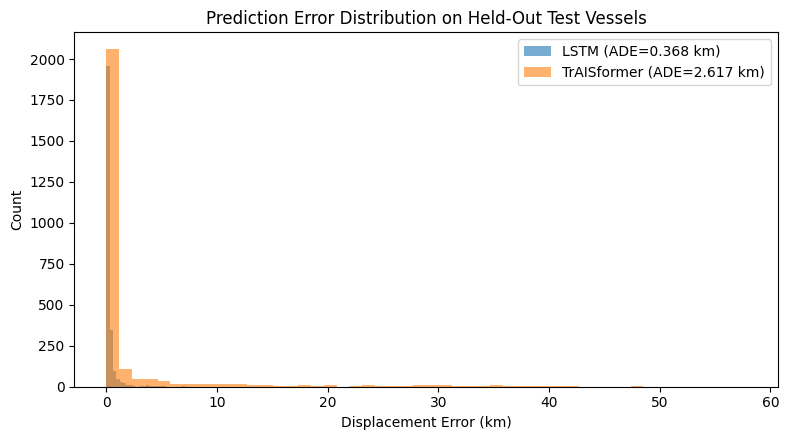

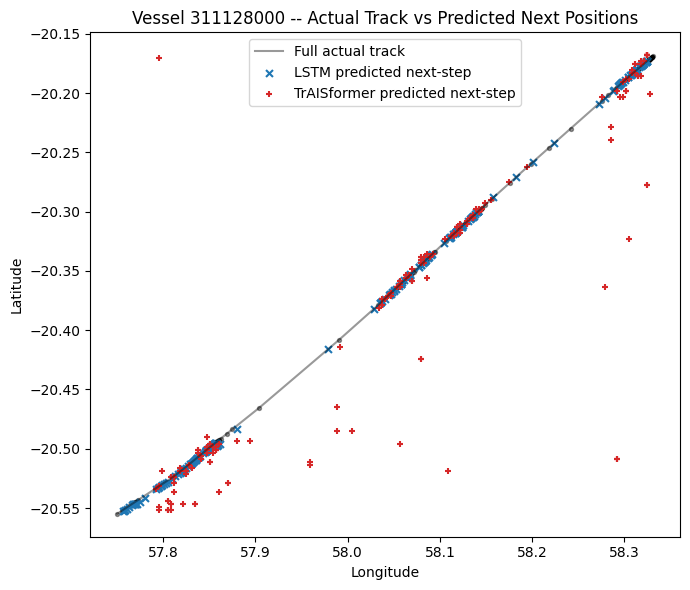

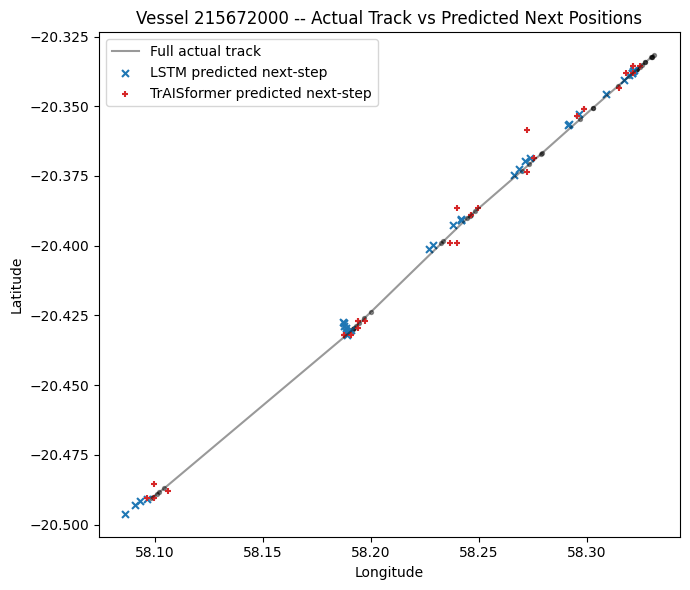

In [10]:
# CELL 10: Visualizations

def plot_training_curves():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(lstm_train_losses, label='Train'); axes[0].plot(lstm_val_losses, label='Val')
    axes[0].set_title('LSTM Baseline -- MSE Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(traisformer_train_losses, label='Train'); axes[1].plot(traisformer_val_losses, label='Val')
    axes[1].set_title('TrAISformer -- Cross-Entropy Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_error_distribution():
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(lstm_errors, bins=50, alpha=0.6, label=f'LSTM (ADE={lstm_errors.mean():.3f} km)')
    ax.hist(traisformer_errors, bins=50, alpha=0.6, label=f'TrAISformer (ADE={traisformer_errors.mean():.3f} km)')
    ax.set_xlabel('Displacement Error (km)'); ax.set_ylabel('Count')
    ax.set_title('Prediction Error Distribution on Held-Out Test Vessels')
    ax.legend(); plt.tight_layout(); plt.show()


@torch.no_grad()
def plot_sample_trajectory(vessel_mmsi, n_context=SEQ_LEN):
    """Overlay actual vs both models' predicted continuation for one held-out vessel."""
    g = df[df['mmsi'] == vessel_mmsi].reset_index(drop=True)
    if len(g) < SEQ_LEN + 5:
        print(f"Vessel {vessel_mmsi} too short to plot"); return

    actual_lat, actual_lon = g['latitude'].values, g['longitude'].values
    seqs, targets = build_sequences(g)
    seqs, targets = np.array(seqs), np.array(targets)

    # LSTM predictions
    X_norm = normalize_features(seqs)
    lstm_preds = lstm_model(torch.tensor(X_norm, dtype=torch.float32).to(device)).cpu().numpy()
    lstm_pred_lat, lstm_pred_lon = denorm_latlon(lstm_preds[:,0], lstm_preds[:,1])

    # TrAISformer predictions
    bins = torch.tensor(discretize(seqs), dtype=torch.long).to(device)
    lat_logits, lon_logits = traisformer_model(bins)
    tf_pred_lat, tf_pred_lon = bin_to_latlon(
        torch.argmax(lat_logits, -1).cpu().numpy(), torch.argmax(lon_logits, -1).cpu().numpy())

    plt.figure(figsize=(7, 6))
    plt.plot(actual_lon, actual_lat, 'k-', alpha=0.4, label='Full actual track')
    plt.scatter(actual_lon, actual_lat, c='black', s=8, alpha=0.4)
    plt.scatter(lstm_pred_lon, lstm_pred_lat, c='tab:blue', s=25, marker='x', label='LSTM predicted next-step')
    plt.scatter(tf_pred_lon, tf_pred_lat, c='tab:red', s=25, marker='+', label='TrAISformer predicted next-step')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.title(f'Vessel {vessel_mmsi} -- Actual Track vs Predicted Next Positions')
    plt.legend(); plt.tight_layout(); plt.show()


plot_training_curves()
plot_error_distribution()

# plot a couple of held-out test vessels
sample_test_vessels = [m for m in test_vessels if (df['mmsi']==m).sum() >= SEQ_LEN+10][:2]
for mmsi in sample_test_vessels:
    plot_sample_trajectory(mmsi)


In [11]:
# CELL 11: Save models & deployment inference hook

torch.save(lstm_model.state_dict(), 'trajectory_lstm_baseline.pth')
torch.save(traisformer_model.state_dict(), 'trajectory_traisformer.pth')

results_summary = pd.DataFrame({
    'Model': ['LSTM Baseline', 'TrAISformer'],
    'ADE_km': [lstm_errors.mean(), traisformer_errors.mean()],
    'Median_km': [np.median(lstm_errors), np.median(traisformer_errors)],
    'P90_km': [np.percentile(lstm_errors,90), np.percentile(traisformer_errors,90)],
})
results_summary.to_csv('trajectory_results_summary.csv', index=False)
print(results_summary)

def predict_next_position(history_df, model_choice='traisformer'):
    """
    Deployment helper for the GUI / AIS-anomaly integration team.
    Input: history_df -- a DataFrame of the last SEQ_LEN AIS pings for one vessel,
           columns ['latitude','longitude','speed','course','rot'], sorted by time.
    Output: (predicted_lat, predicted_lon) for the next ping.
    Usage: compare this to the vessel's ACTUAL next reported position -- the
           displacement between them is your trajectory-deviation signal.
    """
    assert len(history_df) == SEQ_LEN, f"history_df must have exactly {SEQ_LEN} rows"
    seq = history_df[['latitude','longitude','speed','course','rot']].values[None, ...]

    if model_choice == 'lstm':
        x = torch.tensor(normalize_features(seq), dtype=torch.float32).to(device)
        pred = lstm_model(x).detach().cpu().numpy()
        return denorm_latlon(pred[0,0], pred[0,1])
    else:
        bins = torch.tensor(discretize(seq), dtype=torch.long).to(device)
        lat_logits, lon_logits = traisformer_model(bins)
        lat_bin = torch.argmax(lat_logits, -1).item()
        lon_bin = torch.argmax(lon_logits, -1).item()
        return bin_to_latlon(lat_bin, lon_bin)

print("Deployment helper `predict_next_position` ready.")


           Model    ADE_km  Median_km    P90_km
0  LSTM Baseline  0.368480   0.192752  0.626629
1    TrAISformer  2.617471   0.340608  6.782364
Deployment helper `predict_next_position` ready.
